## Problem statement
```bash
Linear Regression models the relationship between an independent variable X and a dependent variable y using the equation:
y = wX + b
where w is the weight (slope) and b is the bias (intercept).
The goal of training is to learn the values of w and b that minimize the error between predicted and actual values, using Gradient Descent and the Mean Squared Error (MSE) loss function:
Loss = (1/n) Σ (y_actual − y_predicted)²
The gradients of the loss with respect to w and b are computed and used to iteratively update the parameters:
w = w − lr × ∂Loss/∂w
b = b − lr × ∂Loss/∂b
This lab is divided into two parts:
•
Part A: Manual implementation of Linear Regression using NumPy (gradients derived and coded by hand).
•
Part B: Implementation of the same problem using PyTorch's nn.Module, autograd, and optimizer. Purwanchal
```

In [ ]:
import torch
import numpy as np
from sklearn.model_selection import train_test_split
print(torch.__version__)
print(torch.version.cuda)

print(torch.cuda.is_available())

2.6.0+cu124
12.4
True


In [3]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA Runtime:", torch.version.cuda)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
CUDA Runtime: 12.4
CUDA Available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
import torch

In [5]:
device = None
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(device)

cuda


In [6]:
m = 0.1234
c = 0.6789
X = np.arange(0,2,0.04)
y = m*X + c

split = int(0.8*len(X))

X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

X_train_tensors = torch.from_numpy(X_train)
y_train_tensors = torch.from_numpy(y_train)
X_test_tensors = torch.from_numpy(X_test)
y_test_tensors = torch.from_numpy(y_test)
print(f"Shape of the X_train is {X_train.shape} and type is {type(X_train)}")
print(f"Shape of X_train_tensor is {X_train_tensors.shape} and type is {type(X_train_tensors)}")

Shape of the X_train is (40,) and type is <class 'numpy.ndarray'>
Shape of X_train_tensor is torch.Size([40]) and type is <class 'torch.Tensor'>


In [7]:
import matplotlib.pyplot as plt
def plot_data(
    X_train=X_train_tensors, y_train = y_train_tensors, X_test = X_test_tensors, y_test = y_test_tensors,
    predictions = None):

    plt.scatter(X_train, y_train, c='b', label= 'Training Data')
    plt.scatter(X_test, y_test, c="r", label='Testing Data')
    if predictions is not None:
        plt.plot(X_test, predictions, c='g', label='Predictions')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(' X vs y')
    plt.legend()
    plt.show()


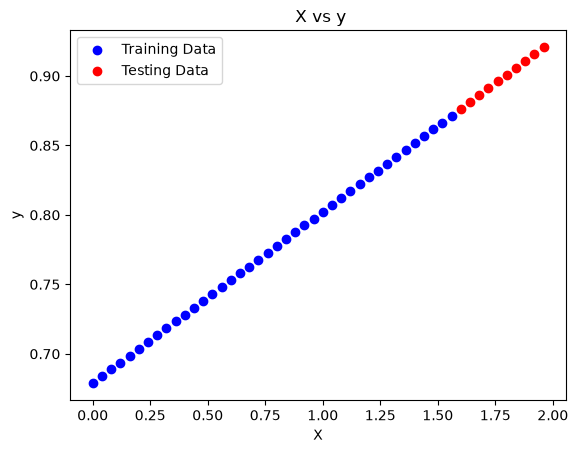

In [8]:
plot_data()

In [9]:
import torch
import torch.nn as nn

class MyFirstNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Parameter instead of nn.parameter
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias   # usually linear form: w*x + b

In [10]:
torch.manual_seed(42)
model = MyFirstNeuralNetwork()
print(model.state_dict())

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])


In [11]:
#Set up loss function and optimizer 
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(
    params = model.parameters(),
    lr = 0.1
) 


In [ ]:
print(next(model.parameters()).device)   # should be cuda:0 or cpu
print(X_train_tensors.device)            # must match
print(y_train_tensors.device)
print(X_test_tensors.device)
print(y_test_tensors.device)


cpu
cpu
cpu
cpu
cpu


In [17]:
# set up the training loop
epochs = 500
train_loss_list = []
test_loss_list = []
# MOve everything to device 
model = model.to(device)

X_train_tensors, y_train_tensors = X_train_tensors.to(device), y_train_tensors.to(device)
X_test_tensors, y_test_tensors = X_test_tensors.to(device), y_test_tensors.to(device)

for epoch in range(epochs):
    #### TRAINING MODE
    model.train()
    #1.FORWARD PASS
    train_preds = model(X_train_tensors)
    #2. COMPUTE THE TRAINING LOSS
    train_loss = loss_fn(y_train_tensors, train_preds)
    #3. ZERO GRAD THE OPTIMIZER
    optimizer.zero_grad()
    #4. BACKPROPAGATE
    train_loss.backward()
    #5.UPDATE THE PARAMETERS
    optimizer.step()
    #### TESTING MODE
    with torch.inference_mode():
        test_preds = model(X_test_tensors)
        test_loss = loss_fn(y_test_tensors, test_preds)
    train_loss_list.append(train_loss.item())
    test_loss_list.append(test_loss.item())

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch}|Train loss {train_loss:.4f}| Test Loss {test_loss:.4f}')

Epoch 49|Train loss 0.0000| Test Loss 0.0000
Epoch 99|Train loss 0.0000| Test Loss 0.0000
Epoch 149|Train loss 0.0000| Test Loss 0.0000
Epoch 199|Train loss 0.0000| Test Loss 0.0000
Epoch 249|Train loss 0.0000| Test Loss 0.0000
Epoch 299|Train loss 0.0000| Test Loss 0.0000
Epoch 349|Train loss 0.0000| Test Loss 0.0000
Epoch 399|Train loss 0.0000| Test Loss 0.0000
Epoch 449|Train loss 0.0000| Test Loss 0.0000
Epoch 499|Train loss 0.0000| Test Loss 0.0000


In [14]:
print(next(model.parameters()).device)   # should be cuda:0 or cpu
print(X_train_tensors.device)            # must match
print(y_train_tensors.device)
print(X_test_tensors.device)
print(y_test_tensors.device)


cuda:0
cuda:0
cuda:0
cuda:0
cuda:0


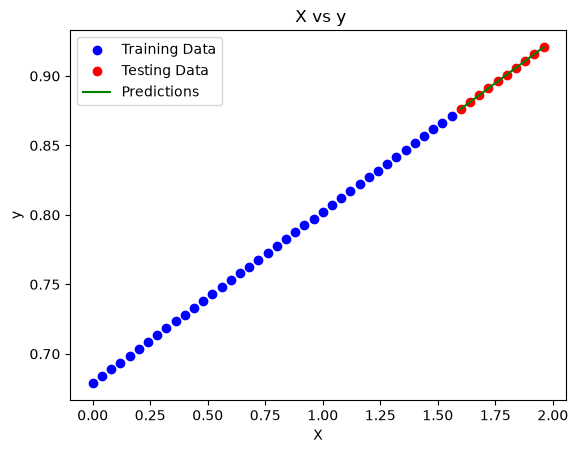

In [15]:
with torch.inference_mode():
    y_pred = model(X_test_tensors)
plot_data(predictions=y_pred.cpu())

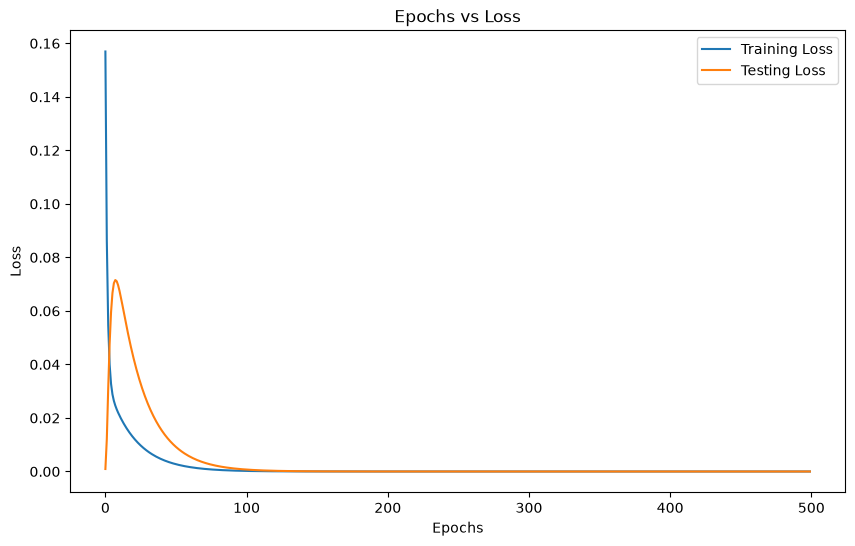

In [16]:
plt.figure(figsize=(10,6))
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.title("Epochs vs Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()